In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/ecommerce_customer_behavior_dataset_v2.csv")

# Create discount flag
df["discount_flag"] = df["Discount_Amount"].apply(
    lambda x: "Discounted Orders" if x > 0 else "Non-Discounted Orders"
)

df.head()


,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating,discount_flag
0,ORD_000001-1,CUST_00001,29-05-2023,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4,Non-Discounted Orders
1,ORD_000001-2,CUST_00001,12-10-2023,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2,Discounted Orders
2,ORD_000001-3,CUST_00001,05-12-2023,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4,Non-Discounted Orders
3,ORD_000002-1,CUST_00002,11-05-2023,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4,Discounted Orders
4,ORD_000002-2,CUST_00002,16-06-2023,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4,Non-Discounted Orders


In [11]:
discount_summary = (
    df.groupby("discount_flag")
      .agg(
          total_orders=("Order_ID", "nunique"),
          total_revenue=("Total_Amount", "sum"),
          avg_order_value=("Total_Amount", "mean")
      )
      .reset_index()
)

discount_summary


,discount_flag,total_orders,total_revenue,avg_order_value
0,Discounted Orders,6477,7630761.82,1178.132132
1,Non-Discounted Orders,10572,14148290.77,1338.279490


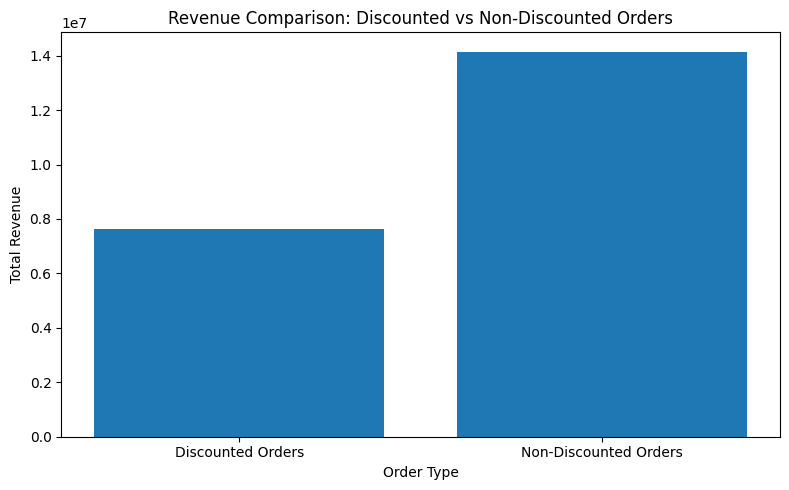

In [12]:
plt.figure(figsize=(8,5))
plt.bar(discount_summary["discount_flag"], discount_summary["total_revenue"])
plt.xlabel("Order Type")
plt.ylabel("Total Revenue")
plt.title("Revenue Comparison: Discounted vs Non-Discounted Orders")
plt.tight_layout()
plt.show()


### Business Insight
Discounted orders generate lower total revenue and lower average order value compared to non-discounted orders. This indicates that discounts are not driving incremental spending or higher order volumes. The current discount strategy appears ineffective and may be eroding profitability, suggesting a need for more targeted or conditional discounting rather than broad promotions.
